In [1]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [2]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_201023_004_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        ntel= data["NTRIGTEL"]
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()
print(df_all_sorted.head())
print(len(df_all_sorted))




astri_001_43_009_00002_R_201023_004_0201_SEB.lv0


astri_002_43_009_00002_R_201023_004_0201_SEB.lv0
astri_003_43_009_00002_R_201023_004_0201_SEB.lv0
astri_004_43_009_00002_R_201023_004_0201_SEB.lv0
astri_005_43_009_00002_R_201023_004_0201_SEB.lv0
astri_006_43_009_00002_R_201023_004_0201_SEB.lv0
astri_007_43_009_00002_R_201023_004_0201_SEB.lv0
astri_008_43_009_00002_R_201023_004_0201_SEB.lv0
astri_009_43_009_00002_R_201023_004_0201_SEB.lv0
   TIME_NS  TIME_S  TIME_ABS  EVENT   MCRUN  TEL_ID  num_tel  \
0   238868       0    238868   1007  263210       2        1   
1  1029262       0   1029262   3519  263210       2        2   
2  1030456       0   1030456   3519  263210       9        2   
3  3274338       0   3274338   3803  263210       9        1   
4  3678725       0   3678725   3805  263210       2        8   

                                                  HG  \
0  [[2156, 2287, 2081, 2114, 2197, 2323, 2141, 22...   
1  [[2069, 2138, 2184, 2049, 2241, 2220, 2179, 22...   
2  [[2126, 2121, 2134, 2208, 2194, 2174, 2226, 22...   

In [3]:
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]


print(len(df_all_sorted))

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []

for (event, mcrun), df_evt in df_all_sorted.groupby(["EVENT", "MCRUN"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "event": event,
            "mcrun": mcrun,
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


4213


In [4]:
def intersection(p1, d1, p2, d2):
    """
    p1, p2 = centroidi
    d1, d2 = direzioni 
    """
    A = np.array([d1, -d2]).T
    b = p2 - p1

    # determinante per capire se sono parallele
    det = np.linalg.det(A)
    if abs(det) < 1e-6:
        return None  
    # risolvi i parametri t
    t = np.linalg.solve(A, b)[0]

    # punto di intersezione
    return p1 + t * d1
inters_hg = []
dfR=pd.DataFrame(results)
for (event, mcrun), df_evt in dfR.groupby(["event", "mcrun"]):

    rette_evt = df_evt["HG"].values

    for i in range(len(rette_evt)):
        tel1 = rette_evt[i]["tel"]
        for j in range(i+1, len(rette_evt)):
            tel2 = rette_evt[j]["tel"]
            if tel1 == tel2: #controllo: no più telescopi nello stesso evento
                continue
    
            P = intersection(rette_evt[i]["p0"], rette_evt[i]["d"],
                             rette_evt[j]["p0"], rette_evt[j]["d"])
            if P is not None:
                inters_hg.append({
                    "event": event,
                    "mcrun": mcrun,
                    "P": P
                })

df_int_hg = pd.DataFrame(inters_hg)
P = np.vstack(df_int_hg["P"].values)
df_int_hg = df_int_hg[np.sqrt(P[:,0]**2 + P[:,1]**2) < 400]
            


In [6]:
from sklearn.cluster import DBSCAN

epsilon = 20
min_samples = 6

results_clusters = []

for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

    # punti di intersezione dell'evento
    P = np.vstack(df_evt["P"].values)

    if len(P) < min_samples:
        continue

    # DBSCAN
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
    labels = dbscan.fit_predict(P)

    # cluster validi (senza rumore)
    cl_labels = set(labels)
    cl_labels.discard(-1)
    n_clusters = len(cl_labels)

    if n_clusters == 0:
        results_clusters.append({
            "event": event,
            "mcrun": mcrun,
            "n_clusters": 0,
            "median_dist": {}
        })
        continue
        continue

    # mediane dei cluster
    centri = []
    for lab in cl_labels:
        centro = np.median(P[labels == lab], axis=0)
        centri.append(centro)

    # distanza retta–mediana (per ogni cluster)
    # ==========================
    dfR_evt = dfR[(dfR["event"] == event) & (dfR["mcrun"] == mcrun)]

    # dizionario: cluster --> lista distanze
    r_median = {lab: [] for lab in cl_labels}

    for r in dfR_evt["HG"]:
        p0 = r["p0"]
        d  = r["d"]

        norm_d = np.linalg.norm(d)
        if norm_d == 0:
            continue

        d_unit = d / norm_d

        # distanza da ciascun centro
        for lab, c in zip(cl_labels, centri):
            v = c - p0
            dist = abs(v[0] * d_unit[1] - v[1] * d_unit[0])
            r_median[lab].append(dist)

    # rimuovo cluster vuoti
    r_median = {lab: np.array(vals) for lab, vals in r_median.items() if len(vals) > 0}

    results_clusters.append({
        "event": event,
        "mcrun": mcrun,
        "n_clusters": n_clusters,
        "median_dist": r_median,
    })


In [7]:

df_res = pd.DataFrame(results_clusters)
prob = df_res["n_clusters"].value_counts(normalize=True)

print("P(0 cluster) =", prob.get(0, 0.0))
print("P(1 cluster) =", prob.get(1, 0.0)) #senza sigma_clipp= 0.806 #con =0.82
print("P(2 cluster) =", prob.get(2, 0.0))#senza sigma clip= 0.181  #con =0.16
print("P(3 cluster) =", prob.get(3, 0.0)) 
#con taglio sull'""energia""migliora notevolmente


P(0 cluster) = 0.22336065573770492
P(1 cluster) = 0.7561475409836066
P(2 cluster) = 0.020491803278688523
P(3 cluster) = 0.0


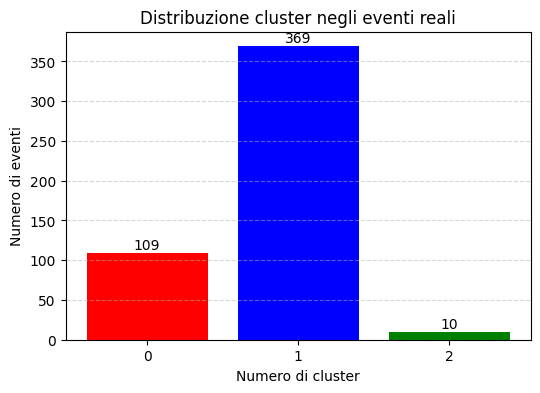

In [7]:
#grafichetto
from collections import Counter

# conto il numero di eventi per numero di cluster
cluster_counts_real = Counter(r["n_clusters"] for r in results_clusters)

# estraggo 0, 1, 2 cluster (o più se serve)
x_labels = [0, 1, 2]
counts = [cluster_counts_real.get(k, 0) for k in x_labels]

# plot
plt.figure(figsize=(6,4))
bars = plt.bar(x_labels, counts, color=['red','blue','green'])
plt.xlabel("Numero di cluster")
plt.ylabel("Numero di eventi")
plt.title("Distribuzione cluster negli eventi reali")
plt.xticks(x_labels)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# aggiungo etichette sulle barre
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, str(height),
             ha='center', va='bottom')

plt.show()


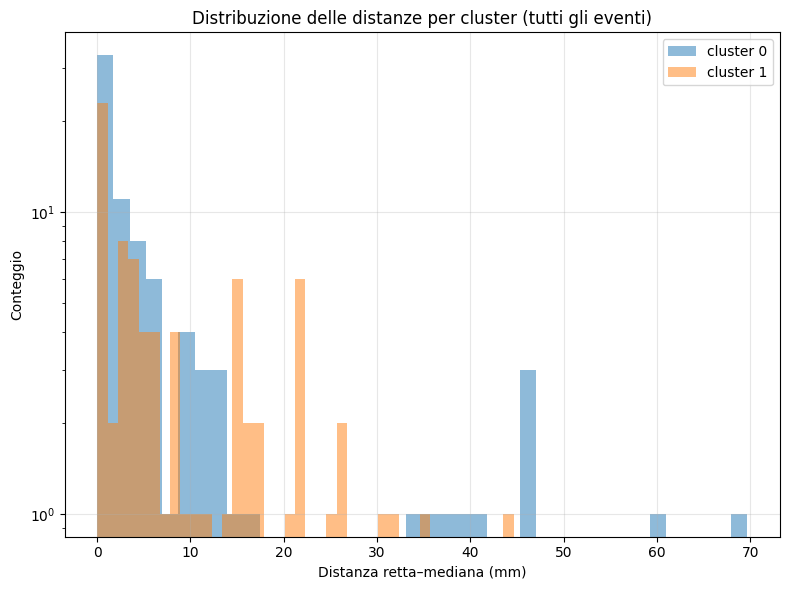

In [8]:
dist_all = {}
df_res1=df_res[df_res["n_clusters"]>1]
for r_median in df_res1["median_dist"]:
    for lab, dlist in r_median.items():
        if lab not in dist_all:
            dist_all[lab] = []
        dist_all[lab].extend(dlist)

plt.figure(figsize=(8, 6))

for lab in sorted(dist_all):
    plt.hist(dist_all[lab],bins=40,alpha=0.5,label=f"cluster {lab}")

plt.xlabel("Distanza retta–mediana (mm)")
plt.ylabel("Conteggio")
plt.title("Distribuzione delle distanze per cluster (tutti gli eventi)")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
import random
#vediamo due eventi presi casualmente
groups = list(df_all_sorted.groupby(["EVENT", "MCRUN"]))
random.shuffle(groups)
groups_A = groups[:len(groups)//2]
groups_B = groups[len(groups)//2:len(groups)]


fake_events = []

for i, ((evtA, dfA), (evtB, dfB)) in enumerate(zip(groups_A, groups_B)):
    if len(dfA) < 3 or len(dfB) < 3:
        continue

    #prendi almeno 3 telescopi da A e non più di quelli disponibili
    nA = max(3, len(dfA) // 2)
    nA = min(nA, len(dfA))
    partA = dfA.sample(n=nA, replace=False)

    #prendi almeno 3 telescopi da B e non più di quelli disponibili
    nB = max(3, len(dfB) // 2)
    nB = min(nB, len(dfB))
    partB = dfB.sample(n=nB, replace=False)

    # unione -> evento fittizio
    df_fake = pd.concat([partA, partB], ignore_index=True)
  
    # etichetta evento fittizio
    df_fake["FAKE_EVENT"] = i
    
    fake_events.append(df_fake)
#dataframe con tutti eventi fittizi
df_fake_all = pd.concat(fake_events, ignore_index=True)
df_fake_all.columns


Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'HG', 'LG',
       'TTP', 'shape', 'FAKE_EVENT'],
      dtype='object')

In [10]:
#########ora stessa analisi di sopra
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []

for fevent, df_evt in df_fake_all.groupby(["FAKE_EVENT"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "r_event": np.array([row["MCRUN"],row["EVENT"]]),
            "fevent": fevent,   
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


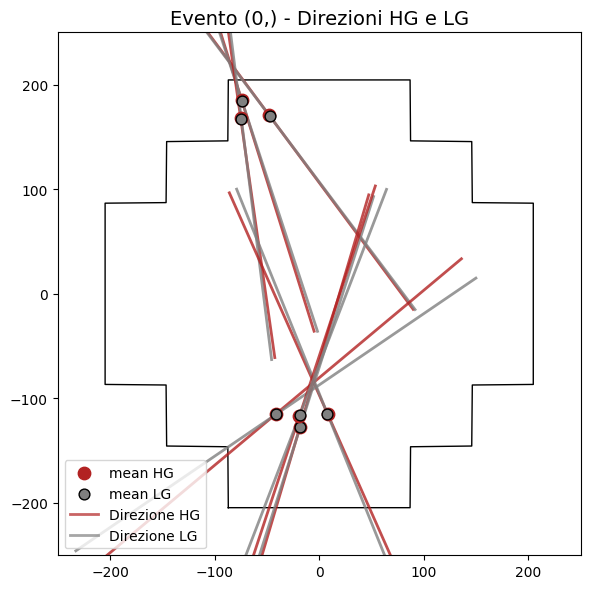

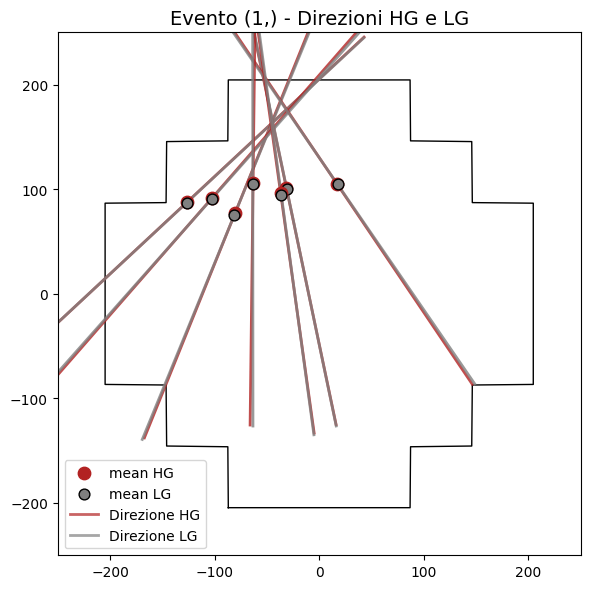

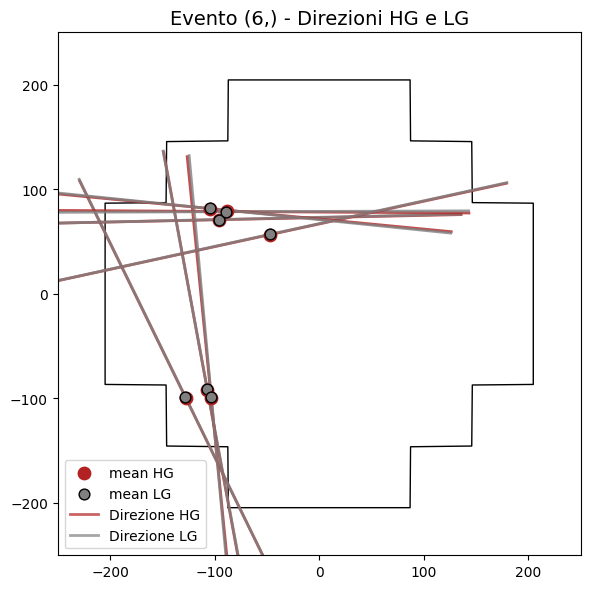

In [11]:
xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
L = 0.40 * diag

# Trova tutti gli eventi presenti
eventi_presenti = sorted({r["fevent"] for r in results})

# Loop su ogni evento
for fevent in eventi_presenti[:3]: #visualizzo i primi 3
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # footprint camera
    ax.plot(xfp, yfp, 'k-', linewidth=1)

    # seleziona tutte le rette di questo evento
    rette_evento = [r for r in results if r["fevent"] == fevent]

    for r in rette_evento:
        # HG
        p0 = r["HG"]["p0"]
        d  = r["HG"]["d"]
        ax.scatter(p0[0], p0[1], s=80, color="firebrick", zorder=5)
        x1, y1 = p0[0] - L*d[0], p0[1] - L*d[1]
        x2, y2 = p0[0] + L*d[0], p0[1] + L*d[1]
        ax.plot([x1, x2], [y1, y2], color="firebrick", linewidth=2, alpha=0.8)

        # LG
        p0 = r["LG"]["p0"]
        d  = r["LG"]["d"]
        ax.scatter(p0[0], p0[1], s=60, color="grey", edgecolor="black", zorder=5)
        x1, y1 = p0[0] - L*d[0], p0[1] - L*d[1]
        x2, y2 = p0[0] + L*d[0], p0[1] + L*d[1]
        ax.plot([x1, x2], [y1, y2], color="grey", linewidth=2, alpha=0.8)
    
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-250, 250)
    ax.set_ylim(-250, 250)
    ax.grid(False)
    ax.set_title(f"Evento {fevent} - Direzioni HG e LG", fontsize=14)
    
    # dummy legends
    ax.scatter([], [], color='firebrick', s=80, label="mean HG")
    ax.scatter([], [], color='grey', s=60, edgecolor='black', label="mean LG")
    ax.plot([], [], color='firebrick', linewidth=2, alpha=0.7, label="Direzione HG")
    ax.plot([], [], color='grey', linewidth=2, alpha=0.7, label="Direzione LG")
    ax.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

In [12]:
def intersection(p1, d1, p2, d2):
    """
    p1, p2 = centroidi
    d1, d2 = direzioni 
    """
    A = np.array([d1, -d2]).T
    b = p2 - p1

    # determinante per capire se sono parallele
    det = np.linalg.det(A)
    if abs(det) < 1e-6:
        return None  
    # risolvi i parametri t
    t = np.linalg.solve(A, b)[0]

    # punto di intersezione
    return p1 + t * d1
inters_hg = []
dfR=pd.DataFrame(results)
for fevent, df_evt in dfR.groupby("fevent"):

    rette_evt = df_evt["HG"].values
    r_event=df_evt["r_event"]
    for i in range(len(rette_evt)):
        tel1 = rette_evt[i]["tel"]
        for j in range(i+1, len(rette_evt)):
            tel2 = rette_evt[j]["tel"]
            if tel1 == tel2: #controllo: no più telescopi nello stesso evento
                continue
    
            P = intersection(rette_evt[i]["p0"], rette_evt[i]["d"],
                             rette_evt[j]["p0"], rette_evt[j]["d"])
            if P is not None:
                inters_hg.append({
                    "fevent": fevent,
                    "r_event": r_event,
                    "P": P
                })

df_int_hg = pd.DataFrame(inters_hg)
P = np.vstack(df_int_hg["P"].values)



#df_int_hg = df_int_hg[np.sqrt(P[:,0]**2 + P[:,1]**2) < 400]
            
#print(df_int_hg.head)

In [13]:
from sklearn.cluster import DBSCAN

epsilon = 15
min_samples = 4

results_clusters = []

for fevent, df_evt in df_int_hg.groupby("fevent"):

    # punti di intersezione dell'evento
    P = np.vstack(df_evt["P"].values)

    if len(P) < min_samples:
        continue

    # DBSCAN
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
    labels = dbscan.fit_predict(P)

    # cluster validi (senza rumore)
    cl_labels = set(labels)
    cl_labels.discard(-1)
    n_clusters = len(cl_labels)

    if n_clusters == 0:
        results_clusters.append({
            "event": event,
            "mcrun": mcrun,
            "n_clusters": 0,
            "median_dist": {}
        })
        continue
    # mediane dei cluster
    centri = []
    for lab in cl_labels:
        centro = np.median(P[labels == lab], axis=0)
        centri.append(centro)

    # ==========================
    # distanza retta–mediana
    # ==========================
    dfR_evt = dfR[(dfR["fevent"] == fevent) ]
    r_median = []
    r_median1=[]
    for r in dfR_evt["HG"]:
        p0 = r["p0"]
        d  = r["d"]

        norm_d = np.linalg.norm(d)
        if norm_d < 1e-6:
            continue

        d_unit = d / norm_d

        # distanza dal cluster più vicino
        dists = []
        for c in centri:
            v = c - p0
            dist = abs(v[0] * d_unit[1] - v[1] * d_unit[0]) #distanza retta mediana
            dists.append(dist)

        if len(dists) == 0:
            continue

        r_median.append(np.min(dists))
        r_median1.append(np.max(dists))
    if len(r_median) == 0:
        continue

    r_median = np.array(r_median)#distanza retta-mediana cluster piu vicino 
    r_median1 = np.array(r_median1)#distanza retta-mediana cluster piu lontano 
    r_event=dfR_evt["r_event"]

    results_clusters.append({
        "fevent": fevent,
        "r_event": r_event,
        "n_clusters": n_clusters,
        "median_dist": r_median,
        "median_dist1": r_median1
    })


In [14]:

df_res = pd.DataFrame(results_clusters)
prob = df_res["n_clusters"].value_counts(normalize=True)

print("P(0 cluster) =", prob.get(0, 0.0))
print("P(1 cluster) =", prob.get(1, 0.0)) #senza sigma_clipp= 0.806 #con =0.82
print("P(2 cluster) =", prob.get(2, 0.0))#senza sigma clip= 0.181  #con =0.16
print("P(3 cluster) =", prob.get(3, 0.0)) 
print("P(4 cluster) =", prob.get(4, 0.0))

P(0 cluster) = 0.3853658536585366
P(1 cluster) = 0.424390243902439
P(2 cluster) = 0.13658536585365855
P(3 cluster) = 0.03414634146341464
P(4 cluster) = 0.01951219512195122


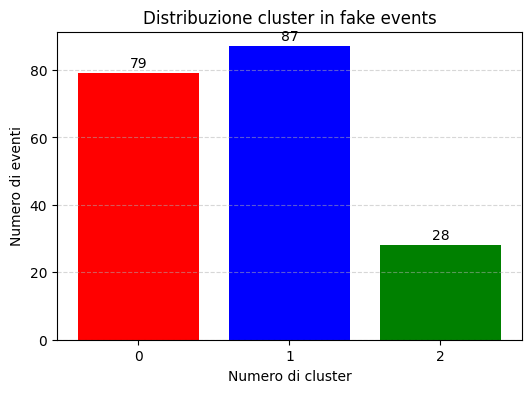

In [15]:
# conto il numero di eventi per numero di cluster
cluster_counts_fake = Counter(r["n_clusters"] for r in results_clusters)

# estraggo 0, 1, 2 cluster
x_labels = [0, 1, 2]
counts = [cluster_counts_fake.get(k, 0) for k in x_labels]

# plot
plt.figure(figsize=(6,4))
bars = plt.bar(x_labels, counts, color=['red','blue','green'])
plt.xlabel("Numero di cluster")
plt.ylabel("Numero di eventi")
plt.title("Distribuzione cluster in fake events")
plt.xticks(x_labels)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# aggiungo etichette sulle barre
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, str(height),
             ha='center', va='bottom')

plt.show()

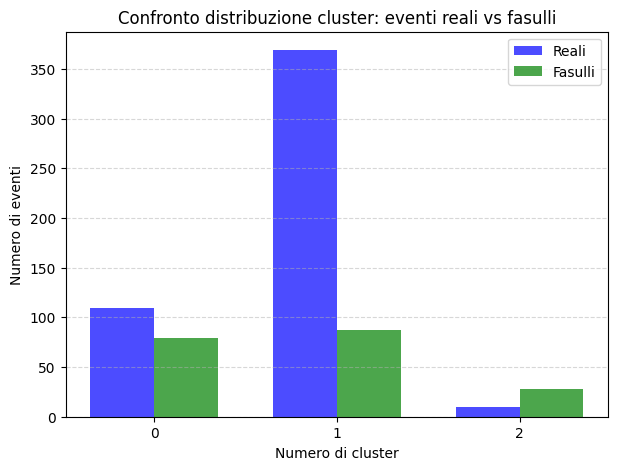

In [16]:


x_labels = [0, 1, 2]  # consideriamo fino a 2 cluster
real_values = [cluster_counts_real.get(k, 0) for k in x_labels]
fake_values = [cluster_counts_fake.get(k, 0) for k in x_labels]

# posizioni delle barre
x = np.arange(len(x_labels))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, real_values, width, label="Reali", color='blue', alpha=0.7)
plt.bar(x + width/2, fake_values, width, label="Fasulli", color='green', alpha=0.7)

plt.xticks(x, x_labels)
plt.xlabel("Numero di cluster")
plt.ylabel("Numero di eventi")
plt.title("Confronto distribuzione cluster: eventi reali vs fasulli")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

TypeError: '<=' not supported between instances of 'float' and 'dict'

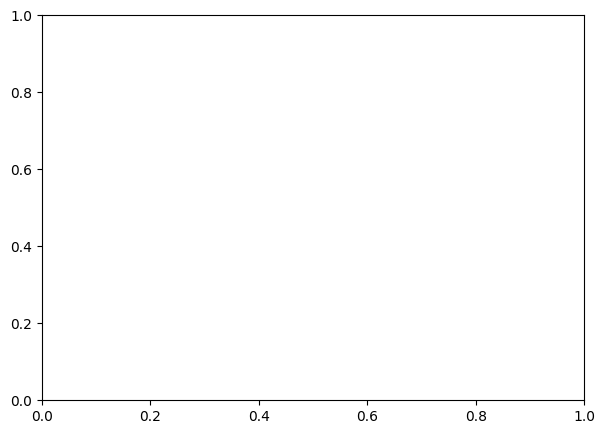

In [17]:

median_dist = np.hstack(df_res["median_dist"].to_list())

if (df_res["n_clusters"] > 1).any():
    median_dist1 = np.hstack(df_res.loc[df_res["n_clusters"] > 1, "median_dist1"].to_list())

# ============================================
# Plot
# ============================================
fig, ax = plt.subplots(figsize=(7, 5))

# --- cluster più vicino ---
ax.hist(median_dist,bins=50,alpha=0.7,color="royalblue",edgecolor="black",
        label="Cluster più vicino")

# --- cluster più lontano (se esiste) --
ax.hist(median_dist1,bins=50,color="firebrick",edgecolor="black",
        label="Cluster più lontano")

# ============================================
# Stile
# ============================================
ax.set_xlabel("Distanza retta–mediana (mm)")
ax.set_ylabel("Conteggio")
ax.set_title("Distribuzione delle distanze retta–mediana (HG)")
ax.legend()
ax.set_yscale("log")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
assigned = []
#############################################################         DA SISTEMARE
for _, row in dfR_evt.iterrows():

    p0 = row["HG"]["p0"]
    d  = row["HG"]["d"]
    true_event = tuple(row["r_event"])

    norm = np.linalg.norm(d)
    if norm == 0:
        continue
    d = d / norm

    # -------------------------
    # distanza retta–cluster
    # -------------------------
    dists = {}
    for lab, c in cluster_centers.items():
        v = c - p0
        dist = abs(v[0]*d[1] - v[1]*d[0])
        dists[lab] = dist

    # -------------------------
    # selezione cluster validi
    # -------------------------
    d_clusters = {lab: d for lab, d in dists.items() if d < 10}

    if len(d_clusters) == 0:
        assigned.append({
            "cluster": -1,
            "true_event": true_event
        })

    elif len(d_clusters) == 1:
        best_cluster = next(iter(d_clusters.keys()))
        assigned.append({
            "cluster": best_cluster,
            "true_event": true_event
        })

    else:
        best_cluster = min(d_clusters, key=d_clusters.get)
        assigned.append({
            "cluster": best_cluster,
            "true_event": true_event
        })

# dataframe finale delle assegnazioni
dfA = pd.DataFrame(assigned)
correct = 0
wrong = 0

for cl in dfA["cluster"].unique():

    if cl == -1:
        continue  # ignoriamo non assegnate

    sub = dfA[dfA["cluster"] == cl]
    true_events = sub["true_event"].unique()

    if len(true_events) == 1:
        correct += len(sub)
    else:
        wrong += len(sub)

total = correct + wrong
accuracy = correct / total if total > 0 else 0

print(f"rette totali     : {total}")
print(f"rette corrette   : {correct}")
print(f"rette sbagliate  : {wrong}")
print(f"accuracy         : {accuracy:.2f}")



NameError: name 'cluster_centers' is not defined